# Q4 - Airline Passengers: Time Series Forecasting with ARIMA

## Settings — the only cell you edit on exam day

In [1]:
# ===================================================================
# EXAM DAY - CHANGE ONLY WHAT IS MARKED BELOW, THEN RUN ALL
# ===================================================================

CSV_FILE  = "Data_Q4.csv"    # <<< CHANGE - the file they give you
DATE_COL  = "Month"          # <<< CHANGE - the date/period column
VALUE_COL = "Passengers"     # <<< CHANGE - the number you are forecasting

TEST_MONTHS     = 24         # <<< CHANGE - how many periods to hold back for testing
SEASONAL_PERIOD = 12         # <<< CHANGE - 12 monthly, 4 quarterly, 7 daily-weekly
ARIMA_ORDER     = (1, 1, 1)  # <<< CHANGE - (p, d, q) if the question specifies one

# If you do not know the column names yet, run this first:
#     import pandas as pd; print(pd.read_csv(CSV_FILE).head())


## Step 1: Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_percentage_error


## Step 2: Load the dataset

In [3]:
df = pd.read_csv(CSV_FILE)
df.head()


,Month,Passengers
0,1949-01,103
1,1949-02,100
2,1949-03,122
3,1949-04,110
4,1949-05,116


## Step 3: Explore the data

In [4]:
print("Shape:", df.shape)     # expect 144 rows x 2 columns (12 years of months)
df.info()


Shape: (144, 2)
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.4 KB


## Step 4: Turn the date column into a time-series index

In [5]:
# dayfirst=True protects against DD-MM-YYYY dates being read as MM-DD-YYYY.
df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True)
df = df.sort_values(DATE_COL)                                  # time must be in order
df = df.set_index(DATE_COL)

series = df[VALUE_COL].astype(float)
series.head()


C:\Users\Tatianv3\AppData\Local\Temp\ipykernel_23204\3521557063.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True)


Month
1949-01-01    103.0
1949-02-01    100.0
1949-03-01    122.0
1949-04-01    110.0
1949-05-01    116.0
Name: Passengers, dtype: float64

## Q4.1 Plot the time series

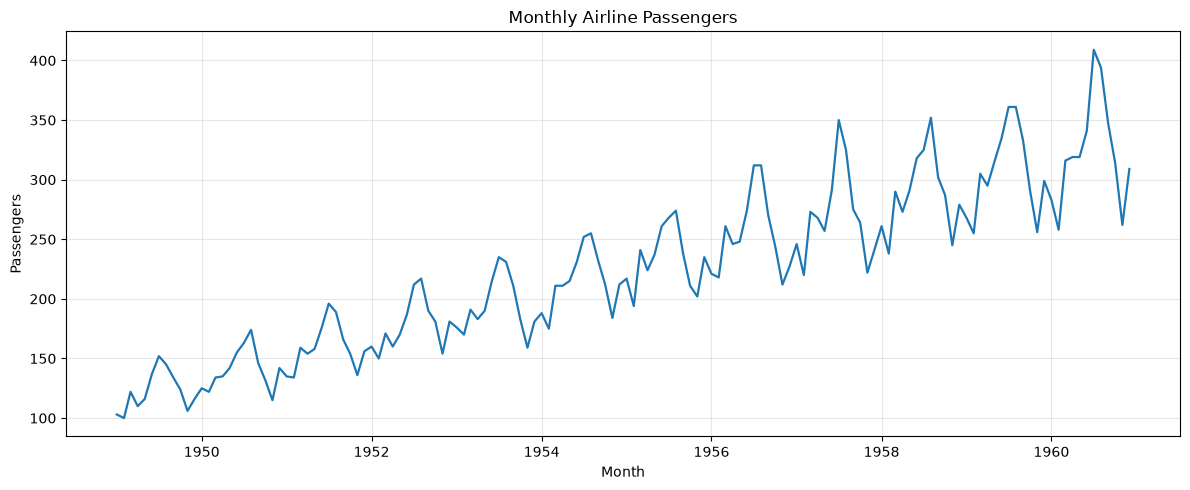

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(series, linewidth=1.6)
plt.title("Monthly Airline Passengers")
plt.xlabel("Month")
plt.ylabel(VALUE_COL)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Reading the plot: a steady climb = TREND,
# the repeating yearly peaks and dips = SEASONALITY.


## Q4.2 Time series decomposition

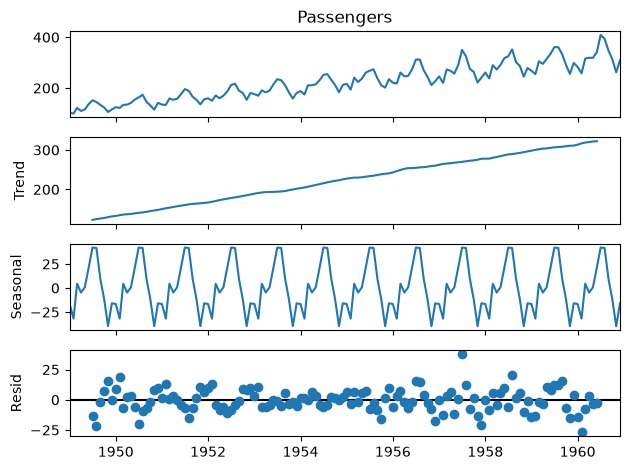

In [7]:
# Splits the series into trend + seasonal + residual (the leftover noise).
result = seasonal_decompose(series, model="additive", period=SEASONAL_PERIOD)

result.plot()
plt.tight_layout()
plt.show()


## Q4.2 The seasonal pattern month by month

In [8]:
# Averaging the seasonal component by month names the busy and quiet months.
seasonal_by_month = result.seasonal.groupby(result.seasonal.index.month).mean().round(2)
seasonal_by_month.index = ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"]
print(seasonal_by_month)


Jan   -16.57
Feb   -31.76
Mar     4.49
Apr    -4.67
May     0.74
Jun    21.42
Jul    42.05
Aug    41.59
Sep     9.53
Oct   -11.45
Nov   -39.56
Dec   -15.82
Name: seasonal, dtype: float64


## Check stationarity before fitting ARIMA

In [9]:
# ARIMA needs a stationary series (stable mean and variance).
# The ADF test: p-value below 0.05 means the series IS stationary.
def adf_test(s, label):
    p = adfuller(s.dropna())[1]
    print(label, "- p-value:", round(p, 4),
          "->", "stationary" if p < 0.05 else "NOT stationary")

adf_test(series, "Original series")
adf_test(series.diff(), "After 1 difference")   # this is the d=1 in ARIMA(p,d,q)


Original series - p-value: 0.8893 -> NOT stationary
After 1 difference - p-value: 0.0 -> stationary


## Q4.3 Split chronologically into train and test

In [10]:
# NEVER use train_test_split on a time series - it would shuffle the dates
# and let the model peek at the future. Slice by position instead.
train = series[:-TEST_MONTHS]
test  = series[-TEST_MONTHS:]

print("Training months:", len(train))
print("Testing months :", len(test))
print("Test period    :", test.index.min().date(), "to", test.index.max().date())


Training months: 120
Testing months : 24
Test period    : 1959-01-01 to 1960-12-01


## Q4.3 Train the ARIMA model

In [11]:
# ARIMA(p, d, q):
#   p = how many past VALUES to use   (AutoRegressive)
#   d = how many times to difference  (Integrated - removes the trend)
#   q = how many past ERRORS to use   (Moving Average)
model = ARIMA(train, order=ARIMA_ORDER)
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -535.048
Date:                Fri, 18 Sep 2026   AIC                           1076.095
Time:                        20:18:46   BIC                           1084.433
Sample:                    01-01-1949   HQIC                          1079.481
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6767      0.119      5.688      0.000       0.444       0.910
ma.L1         -0.8922      0.074    -12.033      0.000      -1.038      -0.747
sigma2       469.4421     64.614      7.265      0.0

C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Q4.3 Forecast the test period

In [12]:
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index          # align the dates so both plot together

pd.DataFrame({"Actual": test, "Forecast": forecast.round(1)}).head(12)


,Actual,Forecast
Month,,
1959-01-01,268.0,279.9
1959-02-01,255.0,280.5
1959-03-01,305.0,280.9
1959-04-01,295.0,281.2
1959-05-01,315.0,281.4
1959-06-01,335.0,281.5
1959-07-01,361.0,281.6
1959-08-01,361.0,281.7
1959-09-01,333.0,281.7


## Q4.4 Evaluate forecast accuracy using MAPE

In [13]:
# MAPE = Mean Absolute Percentage Error - the average error as a percentage.
# Under 10% is generally a good forecast.
mape = mean_absolute_percentage_error(test, forecast) * 100
print("MAPE:", round(mape, 2), "%")

if mape < 10:
    print("The forecast has good accuracy.")
else:
    print("The forecast has a higher error.")


MAPE:

 12.42 %
The forecast has a higher error.


## Q4.4 Plot forecast against actual data

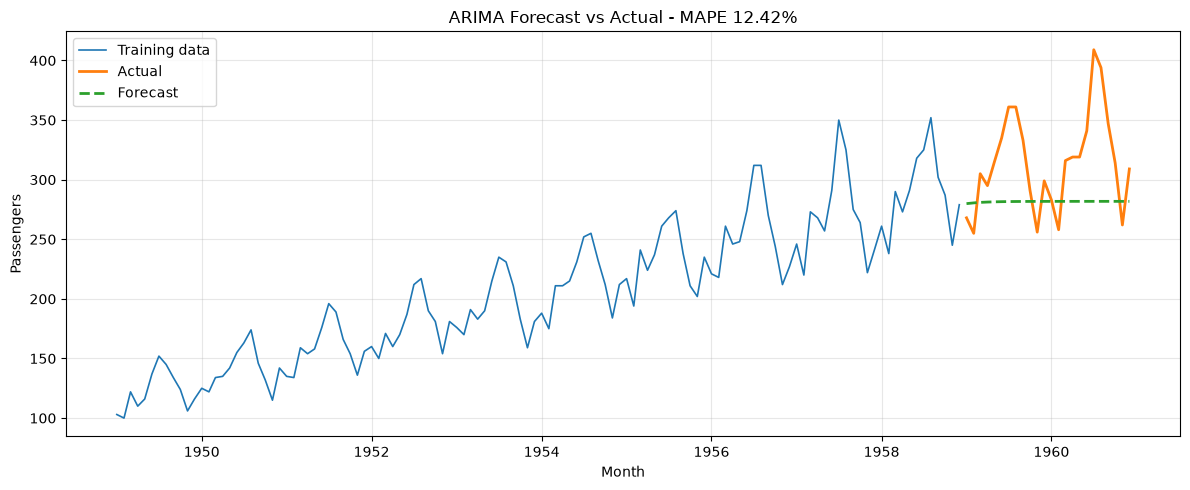

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Training data", linewidth=1.2)
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(forecast.index, forecast, label="Forecast", linewidth=2, linestyle="--")
plt.title("ARIMA Forecast vs Actual - MAPE " + str(round(mape, 2)) + "%")
plt.xlabel("Month")
plt.ylabel(VALUE_COL)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Q4.4 Zoom in on the test period only

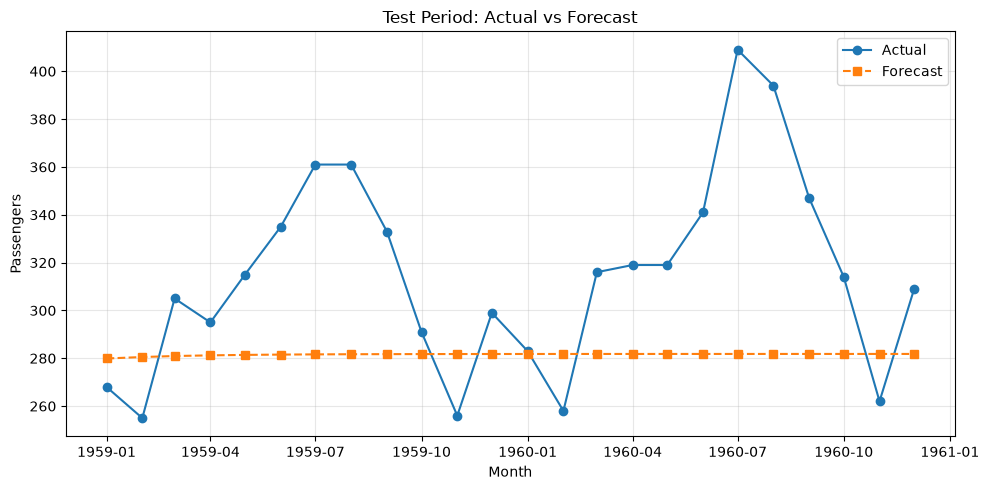

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(test.index, test, marker="o", label="Actual")
plt.plot(forecast.index, forecast, marker="s", linestyle="--", label="Forecast")
plt.title("Test Period: Actual vs Forecast")
plt.xlabel("Month")
plt.ylabel(VALUE_COL)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Comparison table

In [16]:
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast.round(1),
    "Error %": ((test - forecast).abs() / test * 100).round(2)
})
comparison


,Actual,Forecast,Error %
Month,,,
1959-01-01,268.0,279.9,4.44
1959-02-01,255.0,280.5,10.01
1959-03-01,305.0,280.9,7.89
1959-04-01,295.0,281.2,4.67
1959-05-01,315.0,281.4,10.66
1959-06-01,335.0,281.5,15.96
1959-07-01,361.0,281.6,21.98
1959-08-01,361.0,281.7,21.97
1959-09-01,333.0,281.7,15.40


## Extra: SARIMA handles the seasonality that plain ARIMA misses

In [17]:
# Plain ARIMA has no seasonal term, so its forecast comes out smoother than
# the real data. SARIMA adds a seasonal (P,D,Q,s) part - worth a mention in
# the written answer, and usually a much lower MAPE.
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train, order=ARIMA_ORDER,
                 seasonal_order=(1, 1, 1, SEASONAL_PERIOD)).fit(disp=False)

sarima_forecast = sarima.forecast(steps=len(test))
sarima_forecast.index = test.index

sarima_mape = mean_absolute_percentage_error(test, sarima_forecast) * 100
print("ARIMA  MAPE:", round(mape, 2), "%")
print("SARIMA MAPE:", round(sarima_mape, 2), "%")


C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA  MAPE: 12.42 %
SARIMA MAPE: 3.24 %
